In [1]:
from copy import deepcopy

import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "open sans"
from matplotlib.colors import LogNorm

from scipy.optimize import least_squares
from scipy.stats import gaussian_kde

from rdn.validation import Simulation
from rdn.defaults import pardict_from_result
from rdn.fitting.models import LocalGaussModelTilde

Set up the model parameters

In [2]:
model = LocalGaussModelTilde()

model_p_dict = pardict_from_result(
    "output/multi_fitting/Multi_LocalGaussModelTilde/NLLAdast/1_3_5_7_Spine_data_fides_1200.hdf5",
    Chi=1,
    dendrite_length=1000,
    N_mean=5000,
    run_index=0,
)

simulation_time = 40
spine_number = 200
inter_spine_distance = 1

# Usual accounting for shorter dendrite
model_p_dict["Pi"] /= 10

# As discussed
model_p_dict["tau_N"] *= 2
model_p_dict["tau_K"] *= 2

This problem is not to be used without a separately created objective.



Basal K distribution:
- Sample size: 59
- Mean: 4306.707120831921 +- 3034.7652938979772
- Anderson test on log: AndersonResult(statistic=np.float64(0.5220797444867884), critical_values=array([0.554, 0.623, 0.742, 0.861, 1.021]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(8.166348968661676), scale=np.float64(0.6403989835907568))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

Basal N distribution:
- Sample size: 58
- Mean: 8486.0741933069 +- 5297.8956769692495
- Anderson test on log: AndersonResult(statistic=np.float64(0.7266111392522063), critical_values=array([0.553, 0.623, 0.742, 0.861, 1.021]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(8.881617560988888), scale=np.float64(0.5787076967243227))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

Correlation matrix between log K_b and log N_

/home/janko/code/push-pull-code/src/rdn/defaults/pardictfromresult.py:114: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  anderson_res = stats.anderson(log_Xbs)


Import the datasets

In [3]:
bdf = pd.read_csv("data/validation_data/chindemi_data/banerjee.csv")
edf = pd.read_csv("data/validation_data/chindemi_data/egger.csv")
gdf = pd.read_csv("data/validation_data/goda_data/stim_norm_2_vs_base.csv")

Plotting parameters

In [4]:
def rdn_model(x, pp):
    p = 10**pp

    return (1 + p[0] * x ** (pp[1] - 1)) / (1 + p[2] * x ** pp[1])


def power_model(x, p):
    # p = 10**p
    return p[0] * x ** -p[1]


def residual(p, X, Y, model):
    return Y - model(X, p)


def normalize(x):
    return x / x.max()

In [73]:
X = np.concat((normalize(gdf["base_RID"]), normalize(edf["x"])))

Y = np.concat((gdf["norm_2"], edf[" y"]))

THRESHOLD = 1

# Y = np.log(Y)
X = pd.Series(X)
Y = pd.Series(Y)
m = X < THRESHOLD
X = X[m]
Y = Y[m]

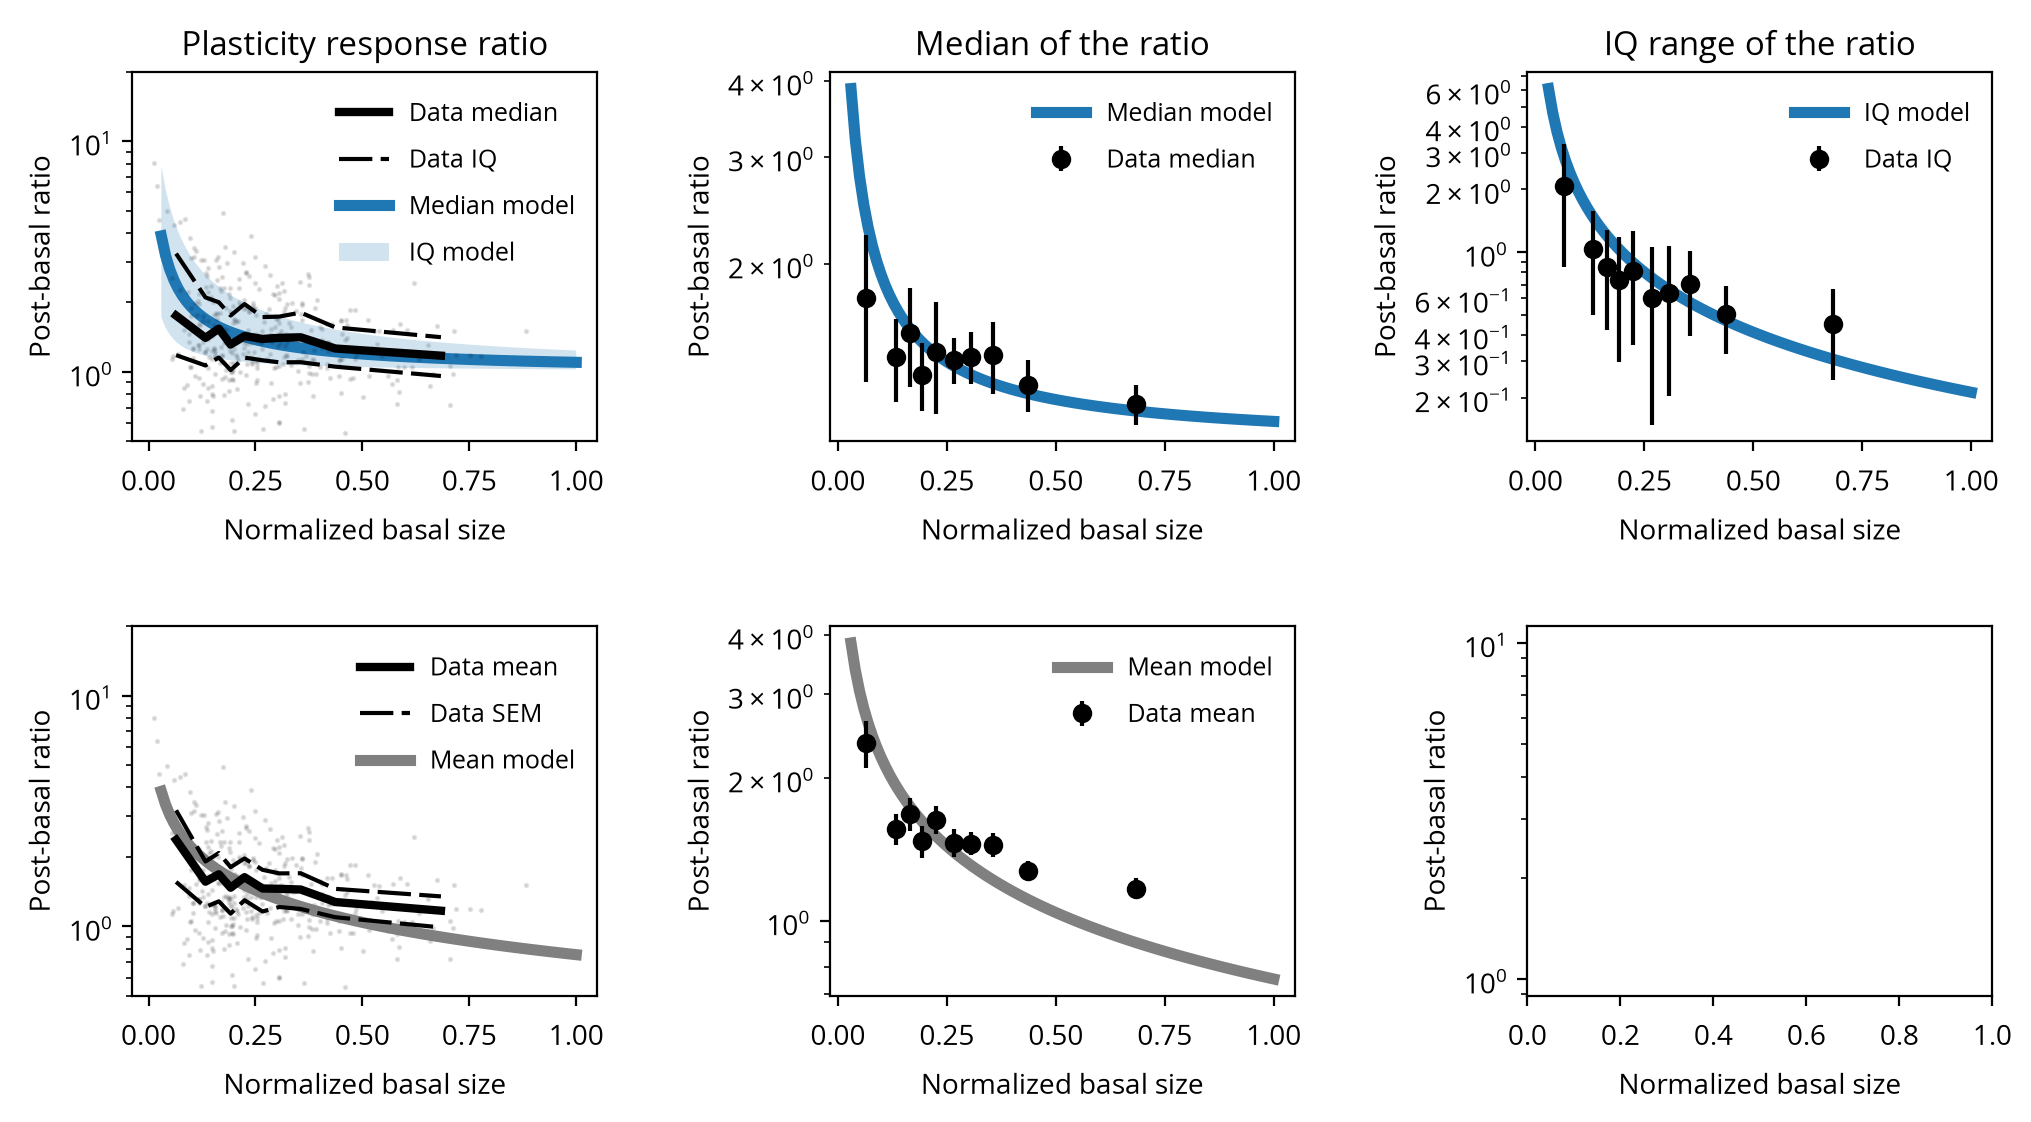

In [91]:
cbins, bins = pd.qcut(X, q=10, retbins=True)
bins = (bins[1:] + bins[:-1]) / 2


def coverage_median(x):
    return (
        x[x.rank(method="first") == 25].item()
        - x[x.rank(method="first") == 14].item()
    ) / 2


def coverage_iq(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    eq1 = (
        x[x.rank(method="first") == 15].item()
        - x[x.rank(method="first") == 5].item()
    ) / 2
    eq3 = (
        x[x.rank(method="first") == 34].item()
        - x[x.rank(method="first") == 24].item()
    ) / 2

    eiq = np.sqrt(eq1**2 + eq3**2)

    return eiq


y = Y.groupby(cbins).agg(
    median="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    mean="mean",
    n=lambda x: len(x),
)

coverage = Y.groupby(cbins).agg(
    median=lambda x: coverage_median(x),
    iq=lambda x: coverage_iq(x),
    mean="sem",
)

med, q1, q3, mean, n = [y.iloc[:, i] for i in range(len(y.T))]

xx = np.linspace(0.03, 1, 100)

p0 = np.ones(4)

res_rdn = least_squares(
    residual, x0=p0, args=(X, Y, rdn_model), loss="soft_l1"
)
res_power = least_squares(
    residual, x0=p0, args=(X, Y, power_model), loss="linear"
)

med_res = np.array(res_rdn.x).copy()
lq_res = med_res.copy()
hq_res = med_res.copy()

lq_res[0] /= 1.6
lq_res[2] /= 1.6
hq_res[0] *= 1.6
hq_res[2] *= 1.6


fig, axs = plt.subplots(2, 3, figsize=(12, 6), dpi=200)

ax = axs[0, 0]
ax.scatter(X, Y, s=1, alpha=0.1, c="black")
ax.plot(bins, med, c="black", zorder=10, lw=3, label="Data median")
ax.plot(bins, q1, c="black", linestyle=(0, (8, 2)), label="Data IQ")
ax.plot(bins, q3, c="black", linestyle=(0, (8, 2)))

ax.plot(
    xx,
    rdn_model(xx, res_rdn.x),
    lw=4,
    c="tab:blue",
    zorder=0,
    label="Median model",
)

ax.fill_between(
    xx,
    rdn_model(xx, lq_res),
    rdn_model(xx, hq_res),
    alpha=0.2,
    label="IQ model",
)
ax.legend(frameon=False, fontsize=9)

ax.set_ylim(0.5, 20)
ax.set_title("Plasticity response ratio")


ax = axs[0, 1]
ax.errorbar(
    bins,
    med,
    yerr=coverage["median"].to_numpy(),
    fmt="o",
    c="black",
    label="Data median",
)
ax.plot(xx, rdn_model(xx, med_res), lw=4, zorder=0, label="Median model")
ax.set_title("Median of the ratio")
ax.legend(frameon=False, fontsize=9)

ax = axs[0, 2]
ax.errorbar(
    bins,
    q3 - q1,
    yerr=coverage["iq"].to_numpy(),
    fmt="o",
    c="black",
    label="Data IQ",
)
ax.plot(
    xx,
    rdn_model(xx, lq_res) - rdn_model(xx, hq_res),
    lw=4,
    zorder=0,
    label="IQ model",
)
ax.legend(frameon=False, fontsize=9)
ax.set_title("IQ range of the ratio")

ax = axs[1, 0]
ax.scatter(X, Y, s=1, alpha=0.1, c="black")
ax.plot(bins, mean, c="black", zorder=10, lw=3, label="Data mean")
ax.plot(
    bins,
    mean - coverage["mean"] * 3,
    c="black",
    linestyle=(0, (8, 2)),
    label="Data SEM",
)
ax.plot(bins, mean + coverage["mean"] * 3, c="black", linestyle=(0, (8, 2)))

ax.plot(
    xx,
    power_model(xx, res_power.x),
    lw=4,
    c="gray",
    zorder=1,
    label="Mean model",
)
ax.set_ylim(0.5, 20)
ax.legend(frameon=False, fontsize=9)

ax = axs[1, 1]
ax.errorbar(
    bins,
    mean,
    yerr=coverage["mean"].to_numpy(),
    fmt="o",
    c="black",
    label="Data mean",
)
ax.plot(
    xx,
    power_model(xx, res_power.x),
    lw=4,
    c="gray",
    zorder=1,
    label="Mean model",
)
ax.legend(frameon=False, fontsize=9)

for ax in axs.flatten():
    ax.set_yscale("log")
    ax.set_xlabel("Normalized basal size")
    ax.set_ylabel("Post-basal ratio")
    # ax.set_ylim(0.5,10)

fig.subplots_adjust(hspace=0.5, wspace=0.5)

<ErrorbarContainer object of 3 artists>

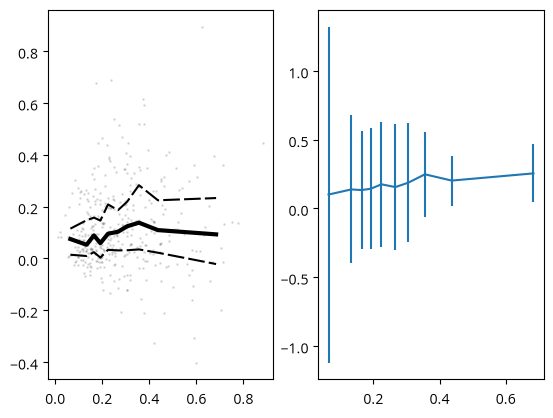

In [89]:
XX = X
YY = Y * X - X

m = XX < 20
XX = XX[m]
YY = YY[m]

cbins, bins = pd.qcut(XX, q=10, retbins=True)
yy = YY.groupby(cbins).agg(
    median="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    n=lambda x: len(x),
)

cyy = Y.groupby(cbins).agg(
    median=lambda x: coverage_median(x),
    iq=lambda x: coverage_iq(x),
    mean="sem",
)

bins = (bins[:-1] + bins[1:]) / 2


fig, axs = plt.subplots(1, 2)

ax = axs[0]
ax.plot(bins, yy["median"], lw=3, c="black")
ax.plot(bins, yy["q1"], c="black", linestyle=(0, (8, 2)))
ax.plot(bins, yy["q3"], c="black", linestyle=(0, (8, 2)))
ax.scatter(XX, YY, s=1, alpha=0.1, c="black")

ax = axs[1]
ax.errorbar(bins, yy["q3"] - yy["q1"], yerr=cyy["iq"])

In [ ]:
yy = YY.groupby(cbins).agg(
    median="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    n=lambda x: len(x),
)

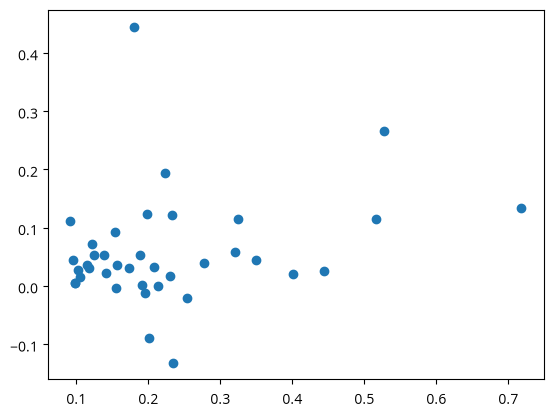

In [92]:
plt.scatter(XX.iloc[:38], YY.iloc[:38])

In [ ]:
def f(x, a):
    return (10 - x) / (1 - x ** (0.04))


x = np.linspace(0.1, 1, 100)
plt.plot(x, f(x, 1))
plt.plot(x, f(x, 2))